<a href="https://colab.research.google.com/github/suryaprasannac-3112/StudentSocialMediaAddictionAnalysis/blob/main/Data_mining_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv(r"/content/teen_phone_addiction_dataset.csv")

summary = {}
print("Original dataset shape:", df.shape)

# ---------------------------
# 1. Remove duplicates
# ---------------------------
initial_rows = len(df)
df = df.drop_duplicates()
summary["duplicates_removed"] = initial_rows - len(df)

# ---------------------------
# 2. Handle missing values
# ---------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

summary["missing_values_handled"] = {
    "numerical": list(num_cols),
    "categorical": list(cat_cols)
}

# ---------------------------
# 3. Standardize categorical columns
# ---------------------------
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

summary["categorical_columns_standardized"] = list(cat_cols)

# ---------------------------
# 4. Fix invalid numeric values (examples)
# ---------------------------
if "Age" in df.columns:
    df["Age"] = df["Age"].clip(lower=10, upper=100)

if "Avg_Daily_Usage_Hours" in df.columns:
    df["Avg_Daily_Usage_Hours"] = df["Avg_Daily_Usage_Hours"].clip(lower=0, upper=24)

if "Sleep_Hours_Per_Night" in df.columns:
    df["Sleep_Hours_Per_Night"] = df["Sleep_Hours_Per_Night"].clip(lower=0, upper=24)

summary["invalid_values_fixed"] = "age, usage hours, sleep hours capped"

# ---------------------------
# 5. Handle outliers using IQR (CAPPING)
# ---------------------------
outliers_capped = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = np.clip(df[col], lower, upper)

    if count > 0:
        outliers_capped[col] = int(count)

summary["outliers_capped"] = outliers_capped

# ---------------------------
# 6. Save cleaned dataset
# ---------------------------
df.to_csv(r"C:\Users\Prasa\OneDrive\Desktop\MERN\Students Social Media Addiction.csv", index=False)

# ---------------------------
# 7. Final outputs
# ---------------------------
print("Cleaned dataset shape:", df.shape)
print("Summary of changes:")
for key, value in summary.items():
    print(f"{key}: {value}")


Original dataset shape: (3000, 25)
Cleaned dataset shape: (3000, 25)
Summary of changes:
duplicates_removed: 0
missing_values_handled: {'numerical': ['ID', 'Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level'], 'categorical': ['Name', 'Gender', 'Location', 'School_Grade', 'Phone_Usage_Purpose']}
categorical_columns_standardized: ['Name', 'Gender', 'Location', 'School_Grade', 'Phone_Usage_Purpose']
invalid_values_fixed: age, usage hours, sleep hours capped
outliers_capped: {'Daily_Usage_Hours': 10, 'Exercise_Hours': 17, 'Screen_Time_Before_Bed': 3, 'Weekend_Usage_Hours': 17, 'Addiction_Level': 96}


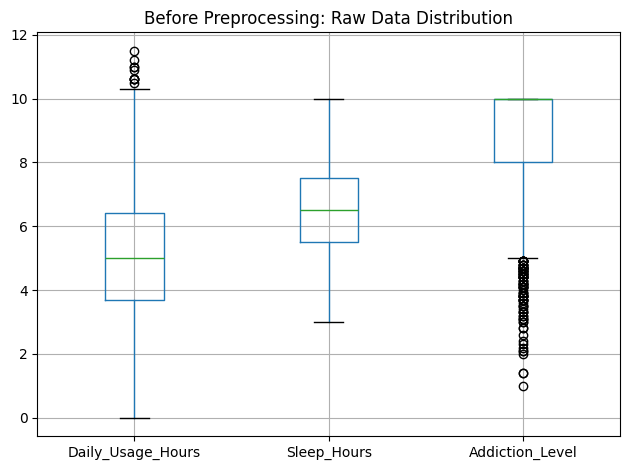

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv(
    r"/content/teen_phone_addiction_dataset.csv"
)

plt.figure()
# Corrected column names based on the actual content of 'teen_phone_addiction_dataset.csv'
# which is the data originally from 'Students Social Media Addiction.csv'
raw[["Daily_Usage_Hours", "Sleep_Hours", "Addiction_Level"]].boxplot()
plt.title("Before Preprocessing: Raw Data Distribution")
plt.tight_layout()
plt.show()

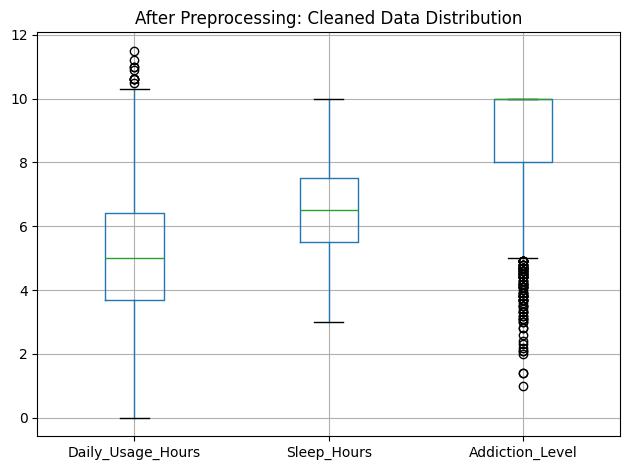

In [ ]:
cleaned = pd.read_csv(
    r"/content/teen_phone_addiction_dataset.csv"
)

plt.figure()
cleaned[["Daily_Usage_Hours", "Sleep_Hours", "Addiction_Level"]].boxplot()
plt.title("After Preprocessing: Cleaned Data Distribution")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv(r"/content/Students Social Media Addiction.csv")

summary = {}
print("Original dataset shape:", df.shape)

# ---------------------------
# 1. Remove duplicates
# ---------------------------
initial_rows = len(df)
df = df.drop_duplicates()
summary["duplicates_removed"] = initial_rows - len(df)

# ---------------------------
# 2. Handle missing values
# ---------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

summary["missing_values_handled"] = {
    "numerical": list(num_cols),
    "categorical": list(cat_cols)
}

# ---------------------------
# 3. Standardize categorical columns
# ---------------------------
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

summary["categorical_columns_standardized"] = list(cat_cols)

# ---------------------------
# 4. Fix invalid numeric values (examples)
# ---------------------------
if "Age" in df.columns:
    df["Age"] = df["Age"].clip(lower=10, upper=100)

if "Avg_Daily_Usage_Hours" in df.columns:
    df["Avg_Daily_Usage_Hours"] = df["Avg_Daily_Usage_Hours"].clip(lower=0, upper=24)

if "Sleep_Hours_Per_Night" in df.columns:
    df["Sleep_Hours_Per_Night"] = df["Sleep_Hours_Per_Night"].clip(lower=0, upper=24)

summary["invalid_values_fixed"] = "age, usage hours, sleep hours capped"

# ---------------------------
# 5. Handle outliers using IQR (CAPPING)
# ---------------------------
outliers_capped = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = np.clip(df[col], lower, upper)

    if count > 0:
        outliers_capped[col] = int(count)

summary["outliers_capped"] = outliers_capped

# ---------------------------
# 6. Save cleaned dataset
# ---------------------------
df.to_csv(r"C:\Users\Prasa\OneDrive\Desktop\MERN\teen_phone_addiction_dataset.csv", index=False)

# ---------------------------
# 7. Final outputs
# ---------------------------
print("Cleaned dataset shape:", df.shape)
print("Summary of changes:")
for key, value in summary.items():
    print(f"{key}: {value}")


Original dataset shape: (705, 13)
Cleaned dataset shape: (705, 13)
Summary of changes:
duplicates_removed: 0
missing_values_handled: {'numerical': ['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score'], 'categorical': ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']}
categorical_columns_standardized: ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']
invalid_values_fixed: age, usage hours, sleep hours capped
outliers_capped: {'Avg_Daily_Usage_Hours': 3}


In [ ]:
import pandas as pd

# ---------------------------
# 1. Load datasets
# ---------------------------
teen = pd.read_csv(
    r"/content/teen_phone_addiction_dataset.csv"
)

social = pd.read_csv(
    r"/content/Students Social Media Addiction.csv"
)

# ---------------------------
# 2. Rename columns for consistency
# ---------------------------
teen.rename(columns={
    "ID": "Student_ID",
    "Daily_Usage_Hours": "Avg_Daily_Usage_Hours",
    "Sleep_Hours": "Sleep_Hours_Per_Night",
    "Academic_Performance": "Affects_Academic_Performance",
    "Addiction_Level": "Addicted_Score",
    "Location": "Country"
}, inplace=True)

# ---------------------------
# 3. Create surrogate Student_ID
# ---------------------------
teen["Student_ID"] = range(1, len(teen) + 1)
social["Student_ID"] = range(1, len(social) + 1)

teen["Student_ID"] = teen["Student_ID"].astype(int)
social["Student_ID"] = social["Student_ID"].astype(int)

# ---------------------------
# 4. Merge datasets
# ---------------------------
integrated_data = pd.merge(
    teen,
    social,
    on="Student_ID",
    how="inner",
    suffixes=("_teen", "_social")
)

# ---------------------------
# 5. Remove duplicate columns
# ---------------------------
integrated_data = integrated_data.loc[
    :, ~integrated_data.columns.duplicated()
]

# ---------------------------
# 6. Save integrated dataset
# ---------------------------
integrated_data.to_csv(
    r"C:\Users\Prasa\OneDrive\Desktop\MERN\integrated_student_addiction_data.csv",
    index=False
)

# ---------------------------
# 7. Output info
# ---------------------------
print("Integrated dataset shape:", integrated_data.shape)
print("Columns:", integrated_data.columns.tolist())


Integrated dataset shape: (705, 37)
Columns: ['Student_ID', 'Name', 'Age_teen', 'Gender_teen', 'Country_teen', 'School_Grade', 'Avg_Daily_Usage_Hours_teen', 'Sleep_Hours_Per_Night_teen', 'Affects_Academic_Performance_teen', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours', 'Addicted_Score_teen', 'Age_social', 'Gender_social', 'Academic_Level', 'Country_social', 'Avg_Daily_Usage_Hours_social', 'Most_Used_Platform', 'Affects_Academic_Performance_social', 'Sleep_Hours_Per_Night_social', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score_social']


In [ ]:
import pandas as pd

# ---------------------------
# 1. File paths
# ---------------------------
teen_path = r"C:\Users\Prasa\OneDrive\Desktop\MERN\teen_phone_addiction_dataset.csv"
social_path = r"C:\Users\Prasa\OneDrive\Desktop\MERN\Students Social Media Addiction.csv"
output_path = r"C:\Users\Prasa\OneDrive\Desktop\MERN\integrated_student_addiction_data.csv"

# ---------------------------
# 2. Load datasets
# ---------------------------
def load_dataset(path, name):
    try:
        df = pd.read_csv(path)
        print(f"{name} dataset loaded successfully. Shape: {df.shape}")
        return df
    except Exception as e:
        print(f"Error loading {name} dataset: {e}")
        return pd.DataFrame()

teen = load_dataset(teen_path, "Teen")
social = load_dataset(social_path, "Social")

# ---------------------------
# 3. Rename columns for consistency
# ---------------------------
rename_map = {
    "ID": "Student_ID",
    "Daily_Usage_Hours": "Avg_Daily_Usage_Hours",
    "Sleep_Hours": "Sleep_Hours_Per_Night",
    "Academic_Performance": "Affects_Academic_Performance",
    "Addiction_Level": "Addicted_Score",
    "Location": "Country"
}
teen.rename(columns=rename_map, inplace=True)

# ---------------------------
# 4. Create surrogate Student_ID
# ---------------------------
teen["Student_ID"] = pd.Series(range(1, len(teen) + 1), dtype=int)
social["Student_ID"] = pd.Series(range(1, len(social) + 1), dtype=int)

# ---------------------------
# 5. Merge datasets
# ---------------------------
integrated_data = pd.merge(
    teen,
    social,
    on="Student_ID",
    how="inner",
    suffixes=("_teen", "_social")
)

# ---------------------------
# 6. Remove duplicate columns
# ---------------------------
integrated_data = integrated_data.loc[:, ~integrated_data.columns.duplicated()]

# ---------------------------
# 7. Save integrated dataset
# ---------------------------
try:
    integrated_data.to_csv(output_path, index=False)
    print(f"Integrated dataset saved successfully at: {output_path}")
except Exception as e:
    print(f"Error saving integrated dataset: {e}")

# ---------------------------
# 8. Output info
# ---------------------------
print("Integrated dataset shape:", integrated_data.shape)
print("Columns:", integrated_data.columns.tolist())

Teen dataset loaded successfully. Shape: (705, 13)
Social dataset loaded successfully. Shape: (3000, 25)
Integrated dataset saved successfully at: C:\Users\Prasa\OneDrive\Desktop\MERN\integrated_student_addiction_data.csv
Integrated dataset shape: (705, 38)
Columns: ['Student_ID', 'Age_teen', 'Gender_teen', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score', 'ID', 'Name', 'Age_social', 'Gender_social', 'Location', 'School_Grade', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Leve

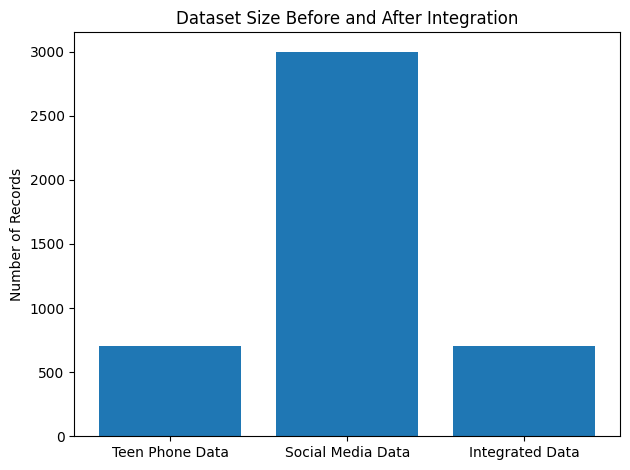

In [ ]:
activity = pd.read_csv(
    r"C:\Users\Prasa\OneDrive\Desktop\MERN\teen_phone_addiction_dataset.csv"
)
social = pd.read_csv(
    r"C:\Users\Prasa\OneDrive\Desktop\MERN\Students Social Media Addiction.csv"
)
integrated = pd.read_csv(
    r"C:\Users\Prasa\OneDrive\Desktop\MERN\integrated_student_addiction_data.csv"
)

sizes = [
    activity.shape[0],
    social.shape[0],
    integrated.shape[0]
]

labels = ["Teen Phone Data", "Social Media Data", "Integrated Data"]

plt.figure()
plt.bar(labels, sizes)
plt.title("Dataset Size Before and After Integration")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


In [ ]:
# Average usage hours per country
reduced_data = integrated_data.groupby("Country")[
    ["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Addicted_Score"]
].mean().reset_index()

print("Reduced dataset shape:", reduced_data.shape)

Reduced dataset shape: (110, 4)


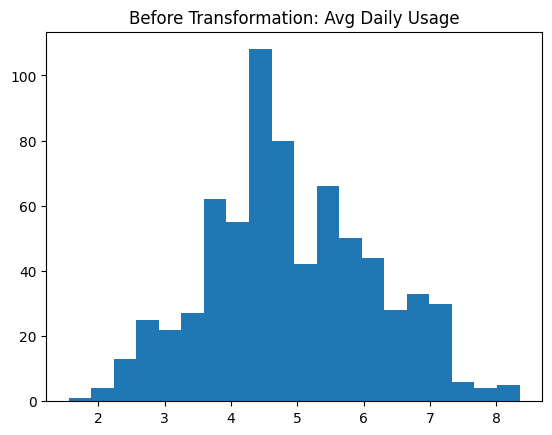

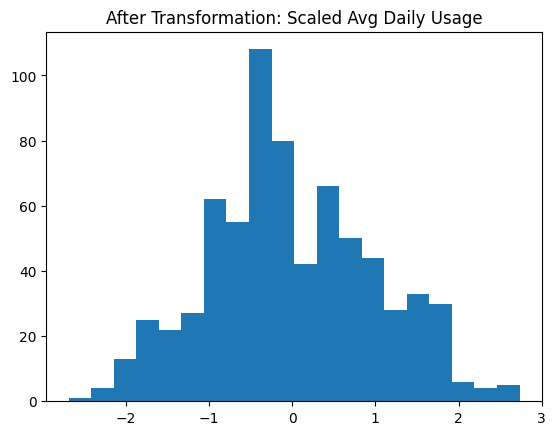

In [ ]:
from sklearn.preprocessing import StandardScaler

data = pd.read_csv(
    r"C:\Users\Prasa\OneDrive\Desktop\MERN\integrated_student_addiction_data.csv"
)

plt.figure()
plt.hist(data["Avg_Daily_Usage_Hours"], bins=20)
plt.title("Before Transformation: Avg Daily Usage")
plt.show()

scaler = StandardScaler()
data["Avg_Daily_Usage_Hours_scaled"] = scaler.fit_transform(
    data[["Avg_Daily_Usage_Hours"]]
)

plt.figure()
plt.hist(data["Avg_Daily_Usage_Hours_scaled"], bins=20)
plt.title("After Transformation: Scaled Avg Daily Usage")
plt.show()


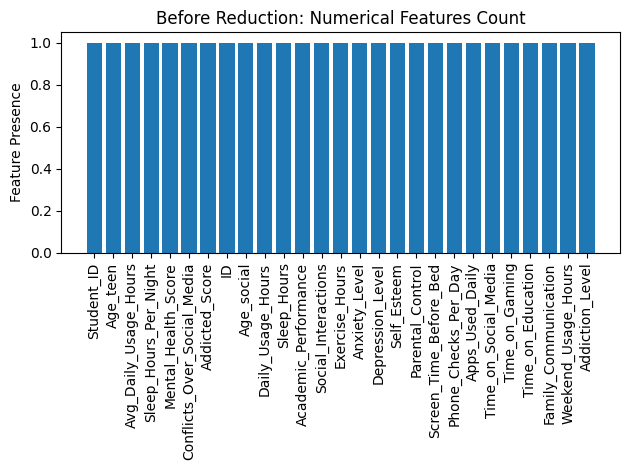

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    r"C:\Users\Prasa\OneDrive\Desktop\MERN\integrated_student_addiction_data.csv"
)

num_cols = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure()
plt.bar(num_cols, [1]*len(num_cols))
plt.xticks(rotation=90)
plt.title("Before Reduction: Numerical Features Count")
plt.ylabel("Feature Presence")
plt.tight_layout()
plt.show()


Selected top 2 highly correlated features: Student_ID and ID


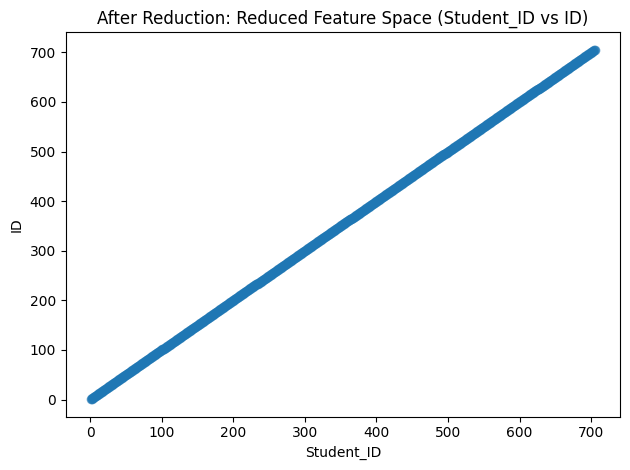

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# `data` and `num_cols` are available from previous cells.

# 1. Calculate the absolute correlation matrix for numerical columns
# Ensure num_cols only contains columns actually present in data
actual_num_cols = [col for col in num_cols if col in data.columns]
correlation_matrix = data[actual_num_cols].corr().abs()

# 2. Extract pairwise correlations, excluding self-correlation
# Get the upper triangle of the correlation matrix to avoid duplicates and self-correlation
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Unstack the upper triangle to get a Series of unique pairwise correlations
correlations_series = upper_tri.stack()

# 3. Filter for correlations above a threshold and sort
# Let's define the threshold as 0.3 as in the original code's intent
strong_correlations = correlations_series[correlations_series > 0.3].sort_values(ascending=False)

# 4. Select the two most highly correlated features for plotting
selected_features = []
if not strong_correlations.empty:
    # Get the index of the highest correlation (a tuple of two feature names)
    feature1, feature2 = strong_correlations.index[0]
    selected_features = [feature1, feature2]
    print(f"Selected top 2 highly correlated features: {selected_features[0]} and {selected_features[1]}")
else:
    print("No strong correlations found above 0.3 among numerical features for plotting.")

# 5. Plot the scatter plot if two features were selected
if len(selected_features) == 2:
    # 'reduced_data' in the original code seems to be 'data' filtered by selected features
    reduced_data = data[selected_features]

    plt.figure()
    plt.scatter(
        reduced_data[selected_features[0]],
        reduced_data[selected_features[1]],
        alpha=0.6
    )
    plt.xlabel(selected_features[0])
    plt.ylabel(selected_features[1])
    plt.title(f"After Reduction: Reduced Feature Space ({selected_features[0]} vs {selected_features[1]})")
    plt.tight_layout()
    plt.show()
else:
    print("Scatter plot could not be generated as fewer than two strongly correlated features were found.")

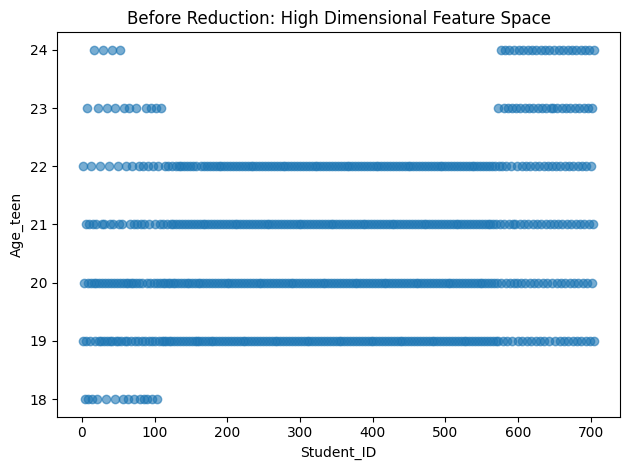

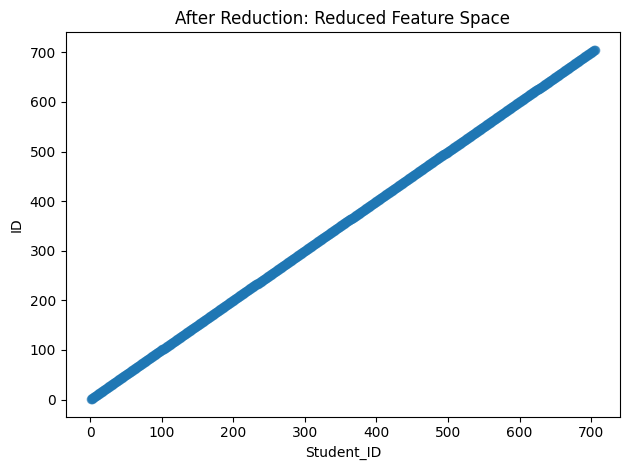

In [ ]:
# BEFORE reduction scatter
plt.figure()
plt.scatter(
    data[num_cols[0]],
    data[num_cols[1]],
    alpha=0.6
)
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.title("Before Reduction: High Dimensional Feature Space")
plt.tight_layout()
plt.show()

# AFTER reduction scatter
reduced_data = data[selected_features]

plt.figure()
plt.scatter(
    reduced_data[selected_features[0]],
    reduced_data[selected_features[1]],
    alpha=0.6
)
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title("After Reduction: Reduced Feature Space")
plt.tight_layout()
plt.show()



Teen Phone Addiction - Before Preprocessing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score    

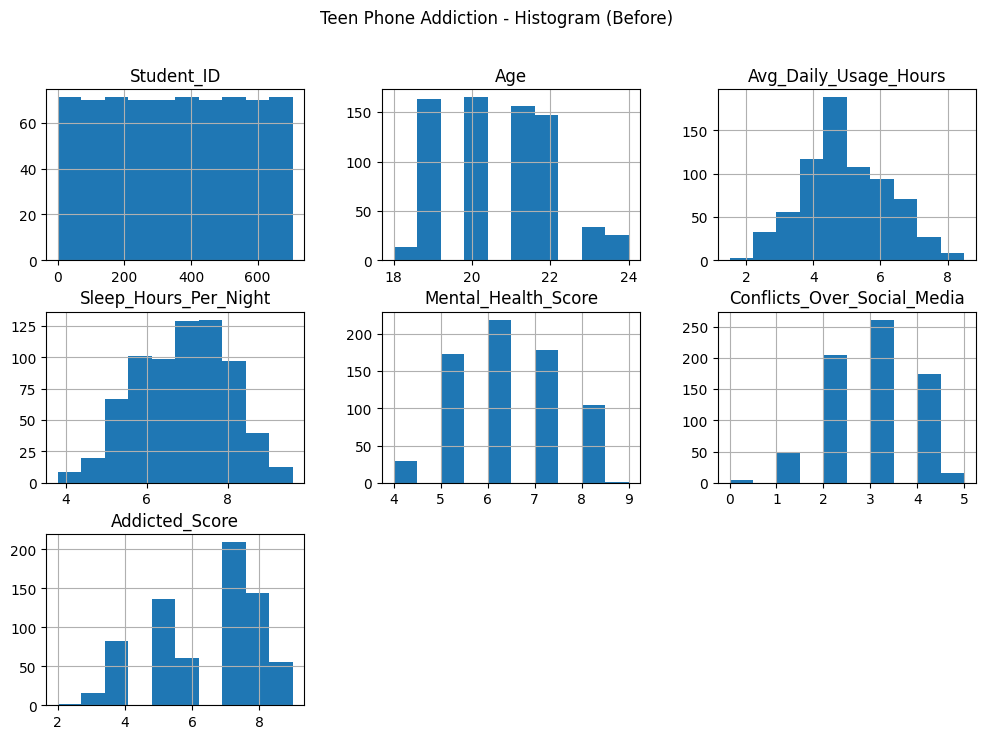

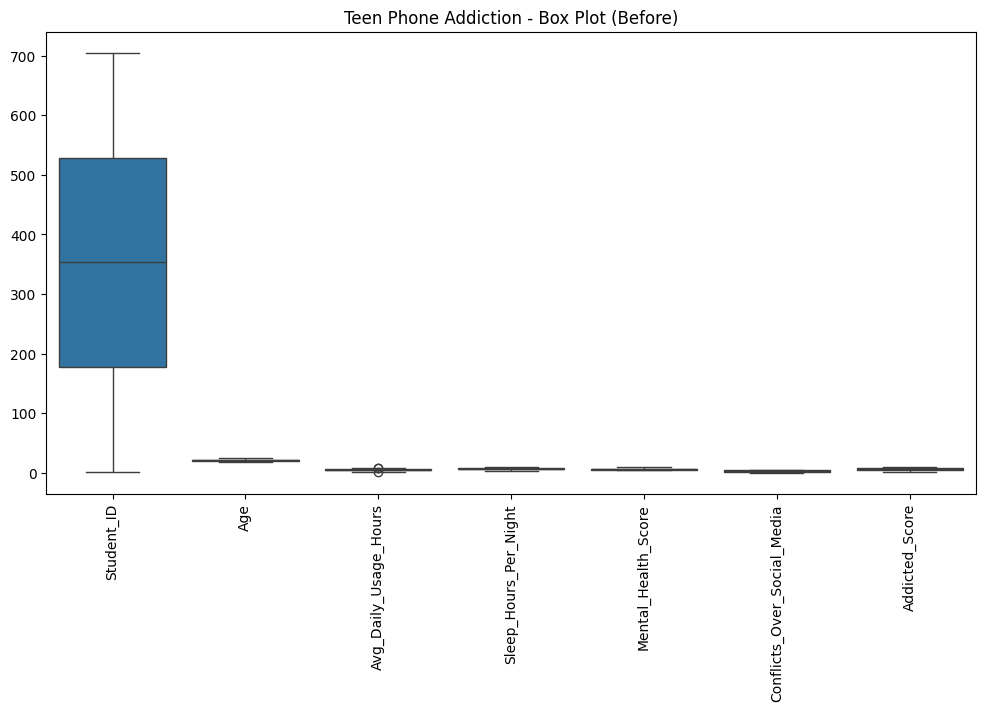

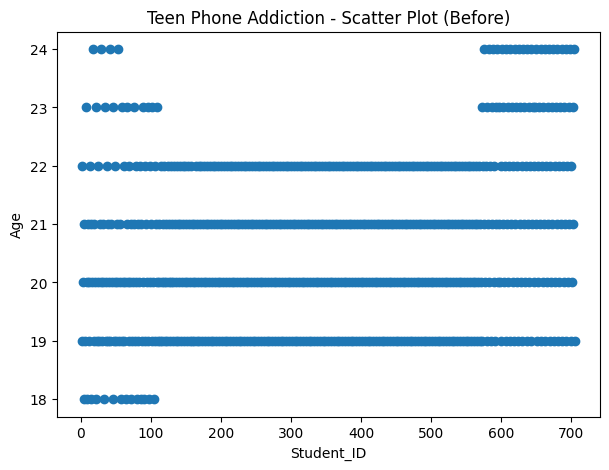

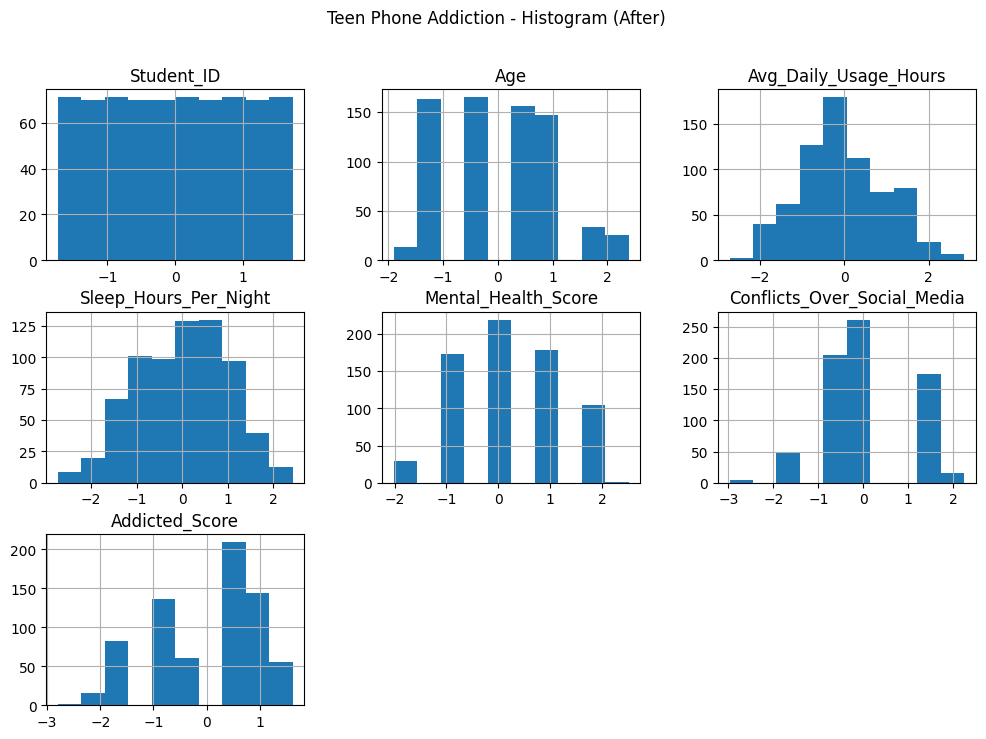

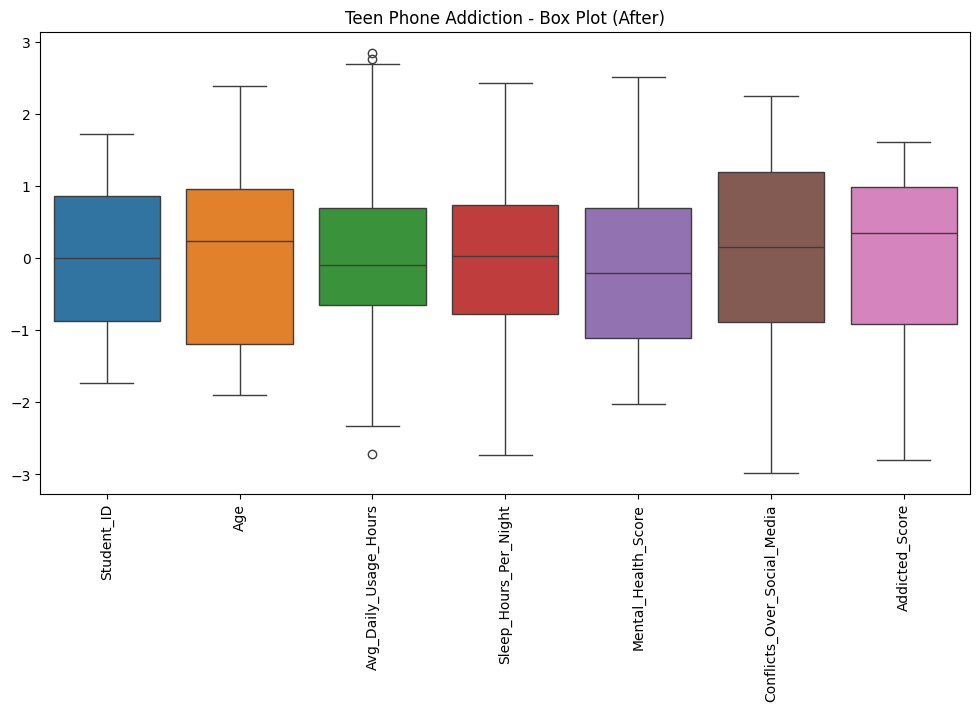

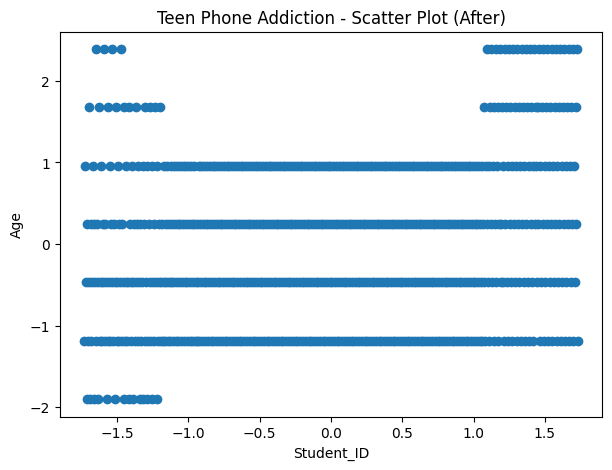


Students Social Media Addiction - Before Preprocessing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-nul

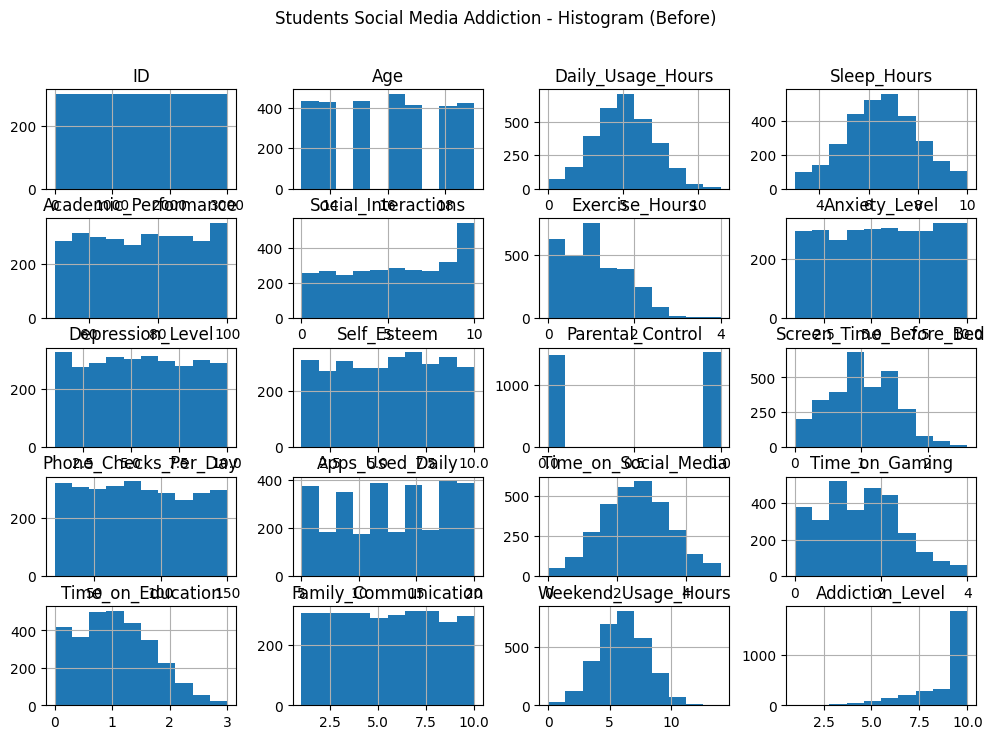

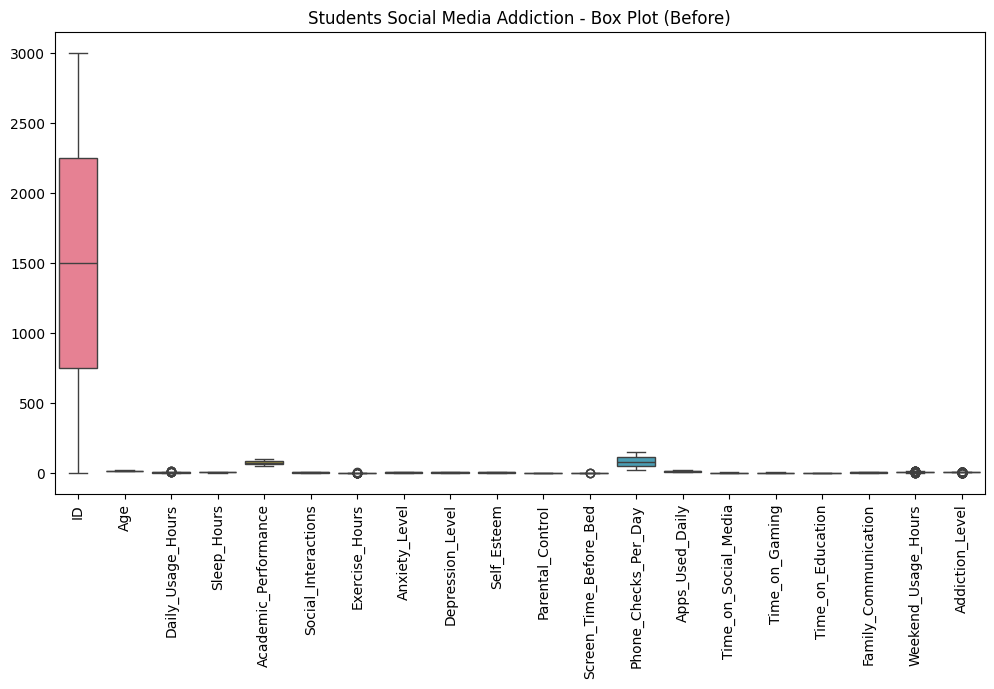

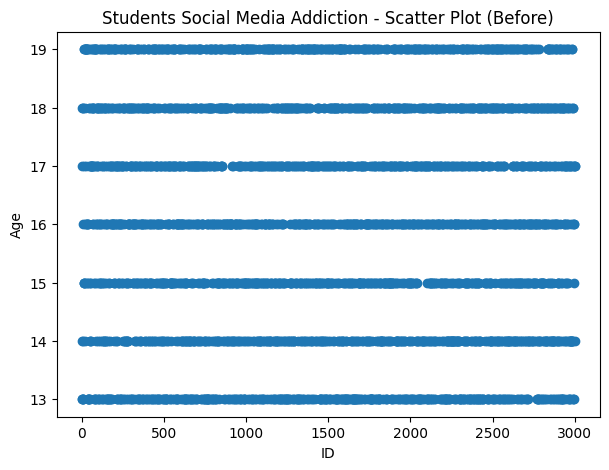

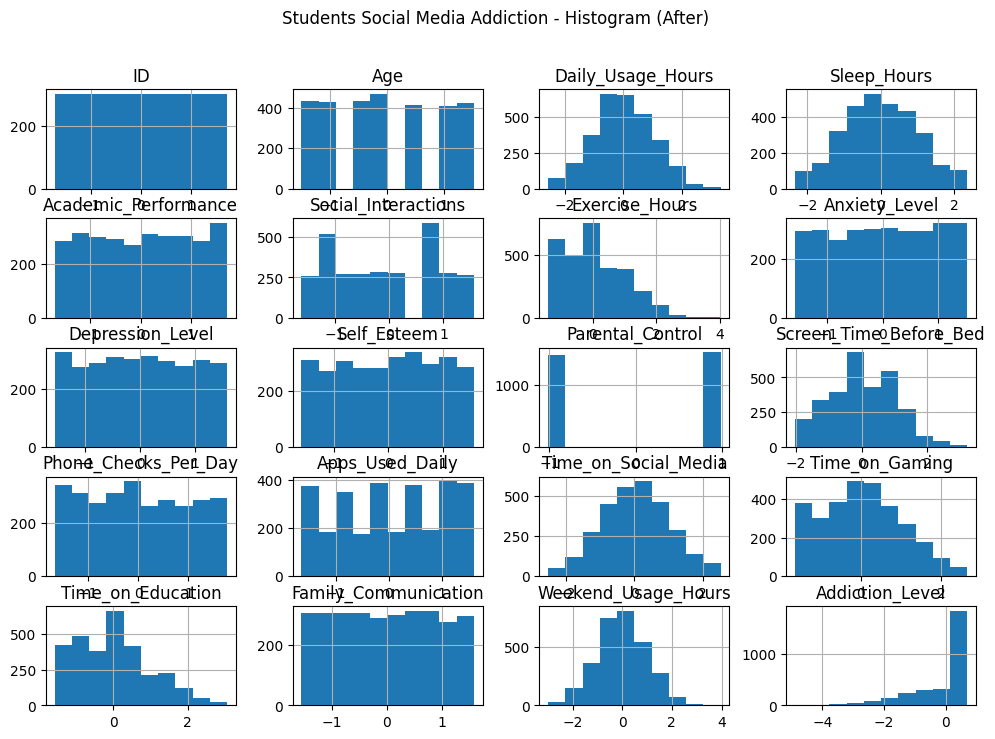

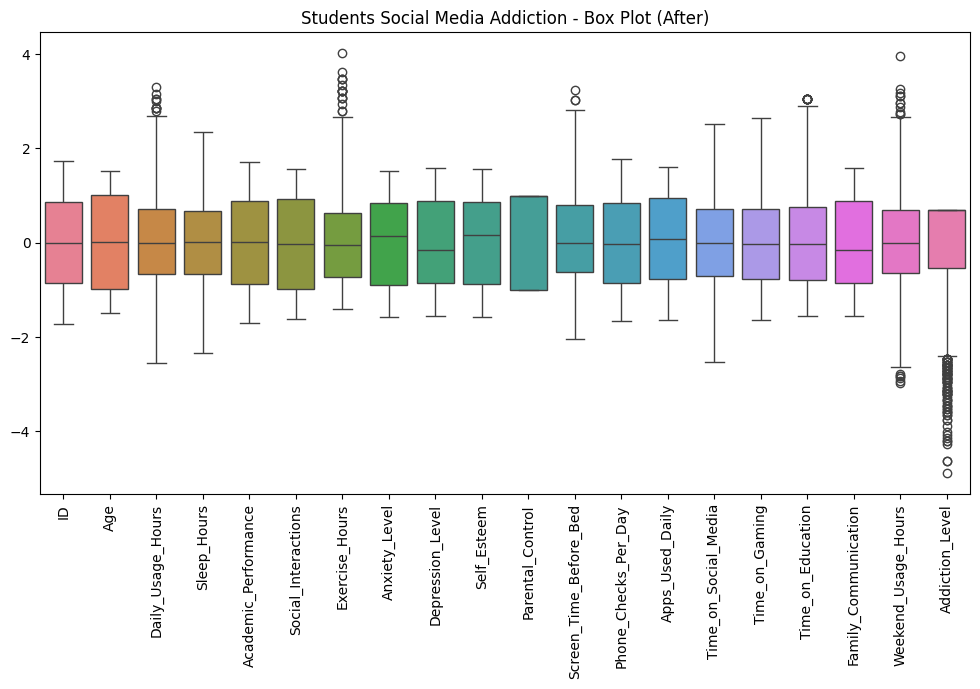

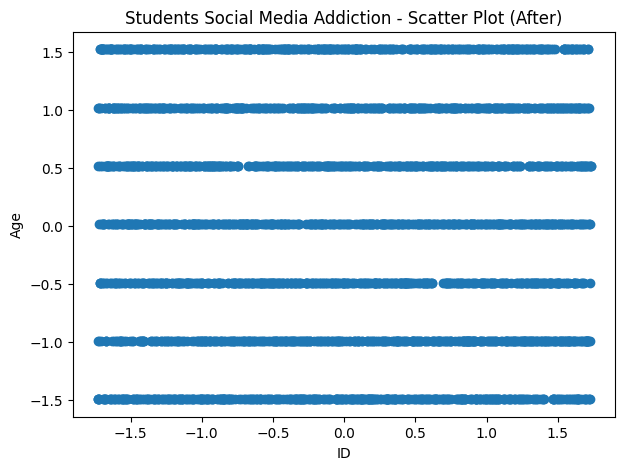

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load datasets
data1 = pd.read_csv("/content/Students Social Media Addiction.csv")
data2 = pd.read_csv("/content/teen_phone_addiction_dataset.csv")

# -------------------------------
# Function: Plot Before Processing
# -------------------------------
def plot_before(data, name):

    print(f"\n{name} - Before Preprocessing\n")
    print(data.info())

    numeric = data.select_dtypes(include=['int64','float64'])

    # Histogram
    numeric.hist(figsize=(12,8))
    plt.suptitle(f"{name} - Histogram (Before)")
    plt.show()

    # Boxplot
    plt.figure(figsize=(12,6))
    sns.boxplot(data=numeric)
    plt.title(f"{name} - Box Plot (Before)")
    plt.xticks(rotation=90)
    plt.show()

    # Scatter (First two numeric columns)
    if numeric.shape[1] >= 2:
        plt.figure(figsize=(7,5))
        plt.scatter(numeric.iloc[:,0], numeric.iloc[:,1])
        plt.xlabel(numeric.columns[0])
        plt.ylabel(numeric.columns[1])
        plt.title(f"{name} - Scatter Plot (Before)")
        plt.show()


# -------------------------------
# Preprocessing
# -------------------------------
def preprocess(data):

    df = data.copy()

    # Handle Missing Values
    df.fillna(df.mean(numeric_only=True), inplace=True)

    # Remove Duplicates
    df.drop_duplicates(inplace=True)

    # Select Numeric Data
    numeric = df.select_dtypes(include=['int64','float64'])

    # Scaling
    scaler = StandardScaler()
    scaled = scaler.fit_transform(numeric)

    df_scaled = pd.DataFrame(scaled, columns=numeric.columns)

    return df_scaled


# -------------------------------
# Function: Plot After Processing
# -------------------------------
def plot_after(data, name):

    # Histogram
    data.hist(figsize=(12,8))
    plt.suptitle(f"{name} - Histogram (After)")
    plt.show()

    # Boxplot
    plt.figure(figsize=(12,6))
    sns.boxplot(data=data)
    plt.title(f"{name} - Box Plot (After)")
    plt.xticks(rotation=90)
    plt.show()

    # Scatter
    if data.shape[1] >= 2:
        plt.figure(figsize=(7,5))
        plt.scatter(data.iloc[:,0], data.iloc[:,1])
        plt.xlabel(data.columns[0])
        plt.ylabel(data.columns[1])
        plt.title(f"{name} - Scatter Plot (After)")
        plt.show()


# ===============================
# DATASET 1
# ===============================

plot_before(data1, "Teen Phone Addiction")

data1_processed = preprocess(data1)

plot_after(data1_processed, "Teen Phone Addiction")


# ===============================
# DATASET 2
# ===============================

plot_before(data2, "Students Social Media Addiction")

data2_processed = preprocess(data2)

plot_after(data2_processed, "Students Social Media Addiction")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your datasets
df1_raw = pd.read_csv("/content/Students Social Media Addiction.csv")
df2_raw = pd.read_csv("/content/teen_phone_addiction_dataset.csv")

# Create copies for processing
df1 = df1_raw.copy()
df2 = df2_raw.copy()

# Convert column names to lowercase (optional but good practice)
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()

print("Dataset-1: Students Social Media Addiction")
print(df1.head())

print("\nDataset-2: Teen Phone Addiction Dataset")
print(df2.head())


Dataset-1: Students Social Media Addiction
   student_id  age  gender academic_level     country  avg_daily_usage_hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  most_used_platform affects_academic_performance  sleep_hours_per_night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   mental_health_sc

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df1_raw = pd.read_csv("Students Social Media Addiction.csv")
df2_raw = pd.read_csv("teen_phone_addiction_dataset.csv")

df1 = df1_raw.copy()
df2 = df2_raw.copy()

df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()

print("Dataset-1")
print(df1.head())

print("Dataset-2")
print(df2.head())


Dataset-1
   student_id  age  gender academic_level     country  avg_daily_usage_hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  most_used_platform affects_academic_performance  sleep_hours_per_night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   mental_health_score relationship_status  conflict

Dataset-1
before first dataset cleaned :
     student_id  age  gender academic_level     country  \
0             1   19  Female  Undergraduate  Bangladesh   
1             2   22    Male       Graduate       India   
2             3   20  Female  Undergraduate         USA   
3             4   18    Male    High School          UK   
4             5   21    Male       Graduate      Canada   
..          ...  ...     ...            ...         ...   
700         701   20  Female  Undergraduate       Italy   
701         702   23    Male       Graduate      Russia   
702         703   21  Female  Undergraduate       China   
703         704   24    Male       Graduate       Japan   
704         705   19  Female  Undergraduate      Poland   

     avg_daily_usage_hours most_used_platform affects_academic_performance  \
0                      5.2          Instagram                          Yes   
1                      2.1            Twitter                           No   
2               

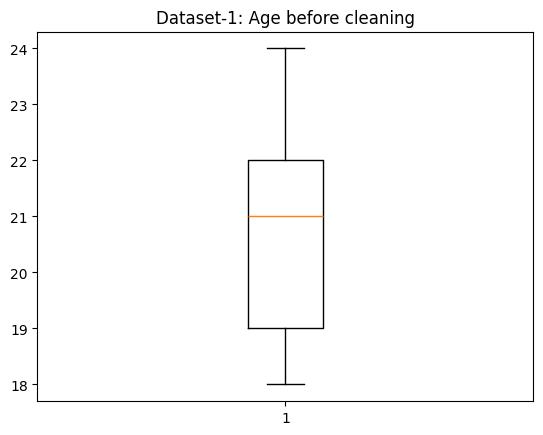

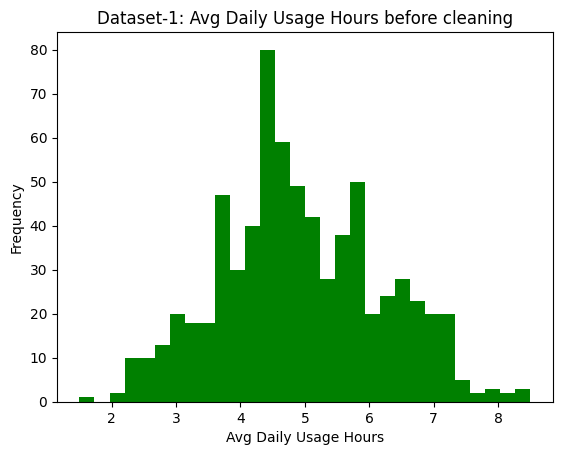

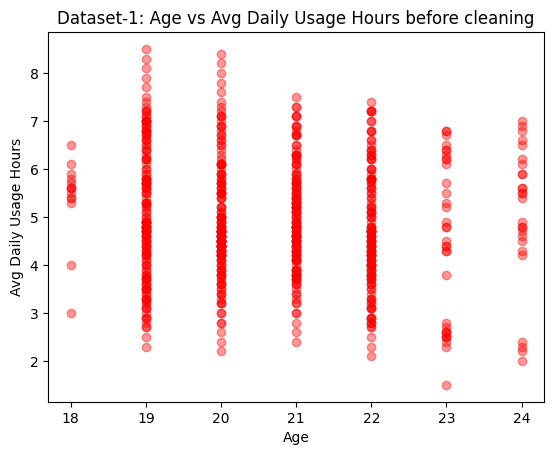

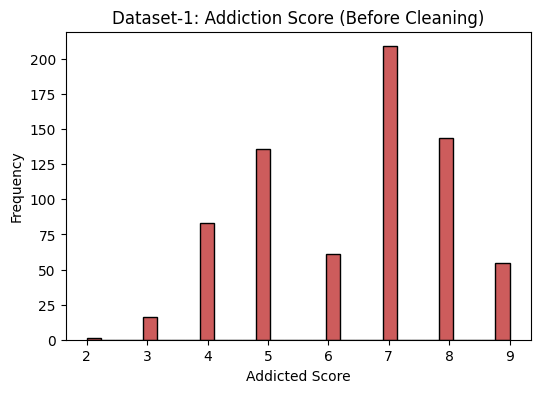

In [ ]:
# ===============================
# BEFORE CLEANING - DATASET 1
# ===============================

print("Dataset-1")
print("before first dataset cleaned :")
print(df1)
print("--------------------------------------------")
print("Missing values for Dataset-1 before cleaning ")
print("--------------------------------------------")
print(df1.isnull().sum())

# Box Plot (Age)
plt.figure()
plt.boxplot(df1['age'].dropna())
plt.title("Dataset-1: Age before cleaning")
plt.show()

# Histogram (Average Daily Usage Hours)
plt.figure()
plt.hist(df1['avg_daily_usage_hours'].dropna(), bins=30, color="green")
plt.title("Dataset-1: Avg Daily Usage Hours before cleaning")
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot (Age vs Avg Daily Usage Hours)
plt.figure()
plt.scatter(df1['age'], df1['avg_daily_usage_hours'], alpha=0.4, color="red")
plt.title("Dataset-1: Age vs Avg Daily Usage Hours before cleaning")
plt.xlabel("Age")
plt.ylabel("Avg Daily Usage Hours")
plt.show()

# Extra Histogram (Addiction Score)
plt.figure(figsize=(6,4))
plt.hist(df1['addicted_score'].dropna(), bins=30, color="indianred", edgecolor="black")
plt.title("Dataset-1: Addiction Score (Before Cleaning)")
plt.xlabel("Addicted Score")
plt.ylabel("Frequency")
plt.show()



In [ ]:
# ===============================
# CLEAN DATASET 1
# ===============================

# Clean Age
df1['age'] = pd.to_numeric(df1['age'], errors='coerce')
df1['age'] = df1['age'].fillna(df1['age'].median())
df1 = df1[(df1['age'] >= 10) & (df1['age'] <= 100)]
df1['age'] = df1['age'].round().astype(int)

# Clean Average Daily Usage Hours
df1['avg_daily_usage_hours'] = pd.to_numeric(df1['avg_daily_usage_hours'], errors='coerce')
df1['avg_daily_usage_hours'] = df1['avg_daily_usage_hours'].fillna(df1['avg_daily_usage_hours'].median())
df1 = df1[(df1['avg_daily_usage_hours'] >= 0) & (df1['avg_daily_usage_hours'] <= 24)]

# Convert to numeric (handle strings / invalid values)
df1['addicted_score'] = pd.to_numeric(df1['addicted_score'], errors='coerce')

# Fill missing values with median
df1['addicted_score'] = df1['addicted_score'].fillna(df1['addicted_score'].median())

# Keep only valid range for addiction score (example: 0 to 100)
df1 = df1[(df1['addicted_score'] >= 0) & (df1['addicted_score'] <= 100)]


after first dataset cleaned :
     student_id  age  gender academic_level     country  \
0             1   19  Female  Undergraduate  Bangladesh   
1             2   22    Male       Graduate       India   
2             3   20  Female  Undergraduate         USA   
3             4   18    Male    High School          UK   
4             5   21    Male       Graduate      Canada   
..          ...  ...     ...            ...         ...   
700         701   20  Female  Undergraduate       Italy   
701         702   23    Male       Graduate      Russia   
702         703   21  Female  Undergraduate       China   
703         704   24    Male       Graduate       Japan   
704         705   19  Female  Undergraduate      Poland   

     avg_daily_usage_hours most_used_platform affects_academic_performance  \
0                      5.2          Instagram                          Yes   
1                      2.1            Twitter                           No   
2                      6.0 

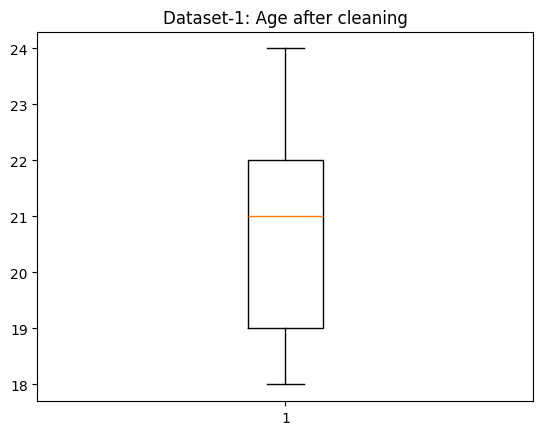

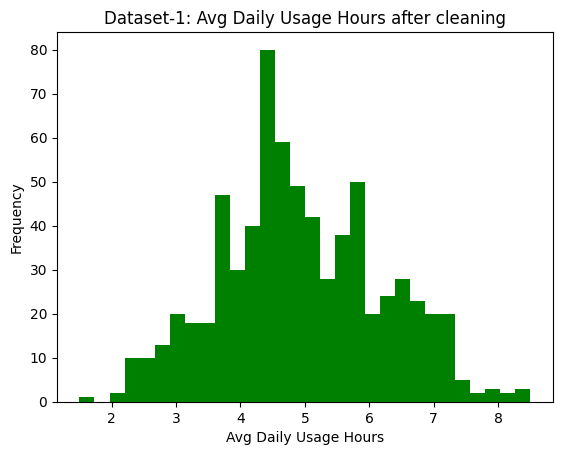

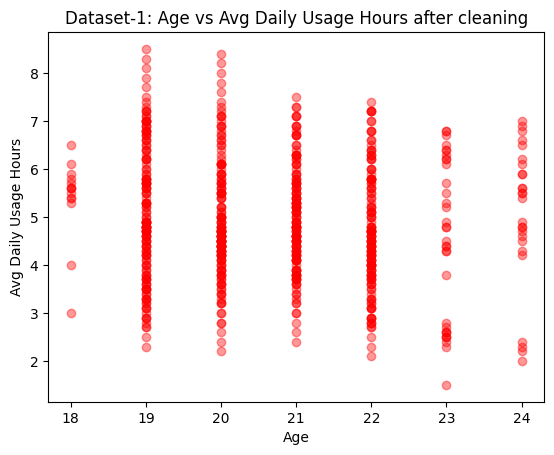

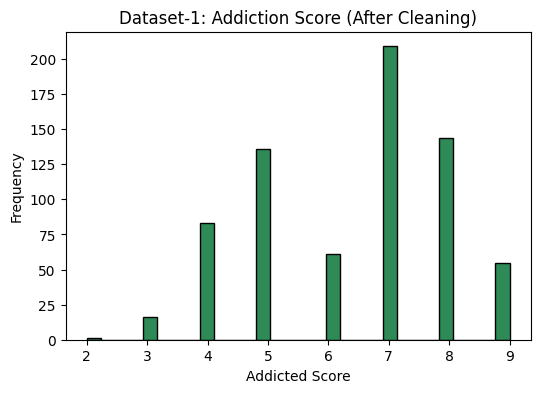

In [ ]:
# ===============================
# AFTER CLEANING - DATASET 1
# ===============================

print("after first dataset cleaned :")
print(df1)
print("--------------------------------------------")
print("Missing values for Dataset-1 after cleaning ")
print("--------------------------------------------")
print(df1.isnull().sum())

# Box Plot (Age)
plt.figure()
plt.boxplot(df1['age'])
plt.title("Dataset-1: Age after cleaning")
plt.show()

# Histogram (Avg Daily Usage Hours)
plt.figure()
plt.hist(df1['avg_daily_usage_hours'], bins=30, color="green")
plt.title("Dataset-1: Avg Daily Usage Hours after cleaning")
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot (Age vs Avg Daily Usage Hours)
plt.figure()
plt.scatter(df1['age'], df1['avg_daily_usage_hours'], alpha=0.4, color="red")
plt.title("Dataset-1: Age vs Avg Daily Usage Hours after cleaning")
plt.xlabel("Age")
plt.ylabel("Avg Daily Usage Hours")
plt.show()

# Extra Histogram (Addiction Score)
plt.figure(figsize=(6,4))
plt.hist(df1['addicted_score'], bins=30, color="seagreen", edgecolor="black")
plt.title("Dataset-1: Addiction Score (After Cleaning)")
plt.xlabel("Addicted Score")
plt.ylabel("Frequency")
plt.show()


Dataset-2
before second dataset cleaned :
        id               name  age  gender          location school_grade  \
0        1    Shannon Francis   13  Female        Hansonfort          9th   
1        2    Scott Rodriguez   17  Female      Theodorefort          7th   
2        3        Adrian Knox   13   Other       Lindseystad         11th   
3        4  Brittany Hamilton   18  Female      West Anthony         12th   
4        5       Steven Smith   14   Other  Port Lindsaystad          9th   
...    ...                ...  ...     ...               ...          ...   
2995  2996        Jesus Yates   16  Female      New Jennifer         12th   
2996  2997     Bethany Murray   13  Female       Richardport          8th   
2997  2998      Norman Hughes   14   Other        Rebeccaton          7th   
2998  2999     Barbara Hinton   17  Female      Ramirezmouth          9th   
2999  3000     Curtis Johnson   17    Male    Lake Alexander         10th   

      daily_usage_hours  sleep_ho

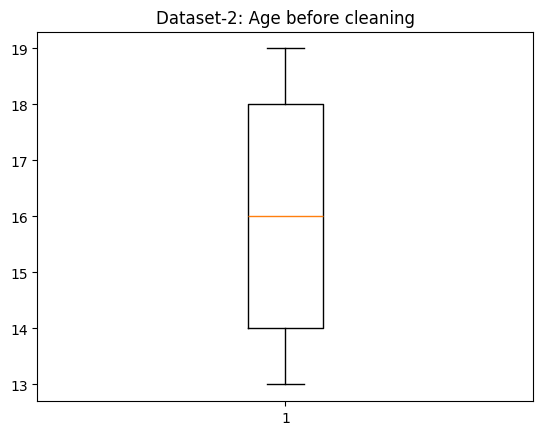

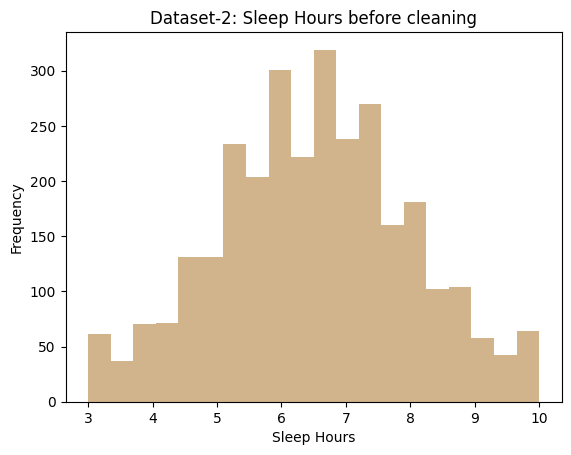

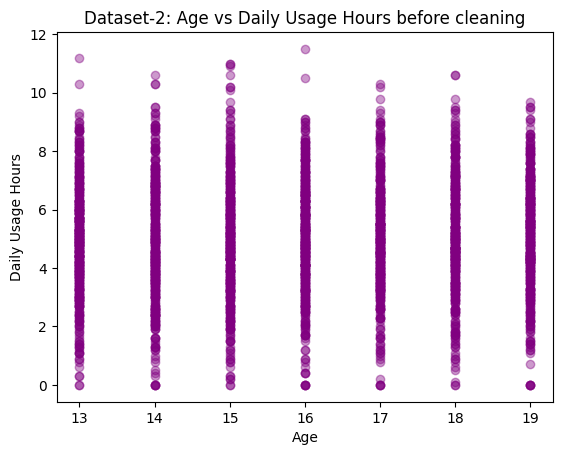

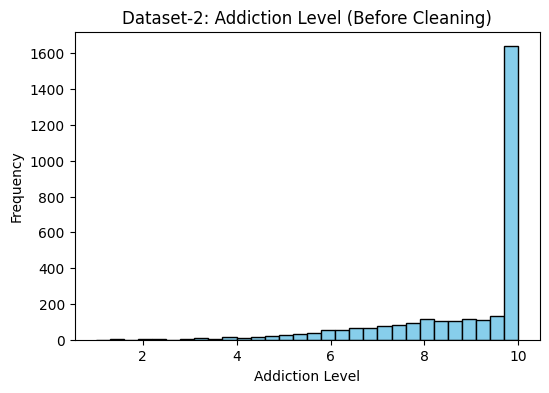

In [ ]:
# ===============================
# BEFORE CLEANING - DATASET 2
# ===============================

print("Dataset-2")
print("before second dataset cleaned :")
print(df2)
print("--------------------------------------------")
print("Missing values for Dataset-2 before cleaning ")
print("--------------------------------------------")
print(df2.isnull().sum())

# Box Plot (Age)
plt.figure()
plt.boxplot(df2['age'].dropna())
plt.title("Dataset-2: Age before cleaning")
plt.show()

# Histogram (Sleep Hours)
plt.figure()
plt.hist(df2['sleep_hours'].dropna(), bins=20, color="tan")
plt.title("Dataset-2: Sleep Hours before cleaning")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot (Age vs Daily Usage Hours)
plt.figure()
plt.scatter(df2['age'], df2['daily_usage_hours'], alpha=0.4, color="purple")
plt.title("Dataset-2: Age vs Daily Usage Hours before cleaning")
plt.xlabel("Age")
plt.ylabel("Daily Usage Hours")
plt.show()

# Extra Histogram (Addiction Level)
plt.figure(figsize=(6,4))
plt.hist(df2['addiction_level'].dropna(), bins=30, color="skyblue", edgecolor="black")
plt.title("Dataset-2: Addiction Level (Before Cleaning)")
plt.xlabel("Addiction Level")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# ===============================
# CLEAN DATASET 2
# ===============================

# Clean Age
df2['age'] = pd.to_numeric(df2['age'], errors='coerce')
df2['age'] = df2['age'].fillna(df2['age'].median())
df2 = df2[(df2['age'] >= 10) & (df2['age'] <= 100)]
df2['age'] = df2['age'].round().astype(int)

# Clean Sleep Hours
df2['sleep_hours'] = pd.to_numeric(df2['sleep_hours'], errors='coerce')
df2['sleep_hours'] = df2['sleep_hours'].fillna(df2['sleep_hours'].median())
df2 = df2[(df2['sleep_hours'] >= 2) & (df2['sleep_hours'] <= 12)]

# Clean Daily Usage Hours
df2['daily_usage_hours'] = pd.to_numeric(df2['daily_usage_hours'], errors='coerce')
df2['daily_usage_hours'] = df2['daily_usage_hours'].fillna(df2['daily_usage_hours'].median())
df2 = df2[(df2['daily_usage_hours'] >= 0) & (df2['daily_usage_hours'] <= 24)]

# Clean Addiction Level
df2['addiction_level'] = pd.to_numeric(df2['addiction_level'], errors='coerce')
df2['addiction_level'] = df2['addiction_level'].fillna(df2['addiction_level'].median())
df2 = df2[(df2['addiction_level'] >= 0) & (df2['addiction_level'] <= 100)]


after second dataset cleaned :
        id               name  age  gender          location school_grade  \
0        1    Shannon Francis   13  Female        Hansonfort          9th   
1        2    Scott Rodriguez   17  Female      Theodorefort          7th   
2        3        Adrian Knox   13   Other       Lindseystad         11th   
3        4  Brittany Hamilton   18  Female      West Anthony         12th   
4        5       Steven Smith   14   Other  Port Lindsaystad          9th   
...    ...                ...  ...     ...               ...          ...   
2995  2996        Jesus Yates   16  Female      New Jennifer         12th   
2996  2997     Bethany Murray   13  Female       Richardport          8th   
2997  2998      Norman Hughes   14   Other        Rebeccaton          7th   
2998  2999     Barbara Hinton   17  Female      Ramirezmouth          9th   
2999  3000     Curtis Johnson   17    Male    Lake Alexander         10th   

      daily_usage_hours  sleep_hours  academ

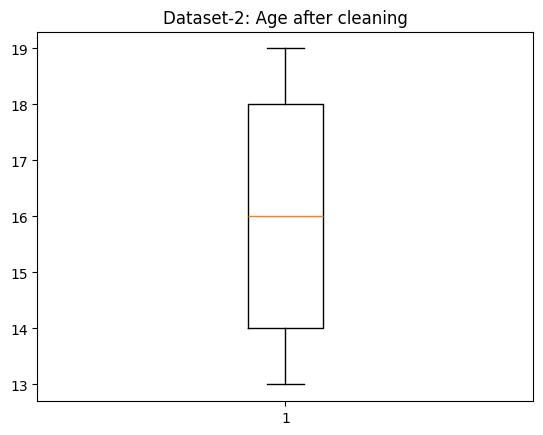

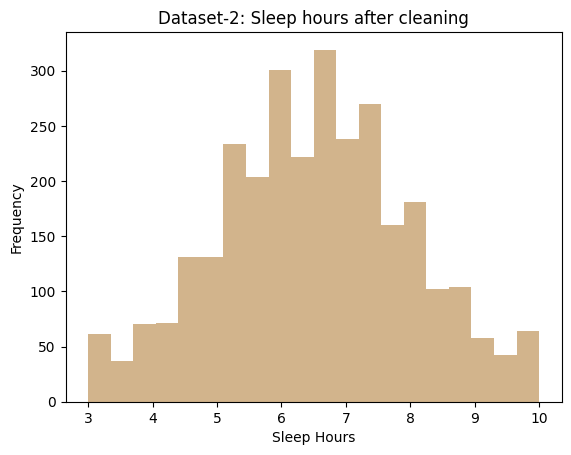

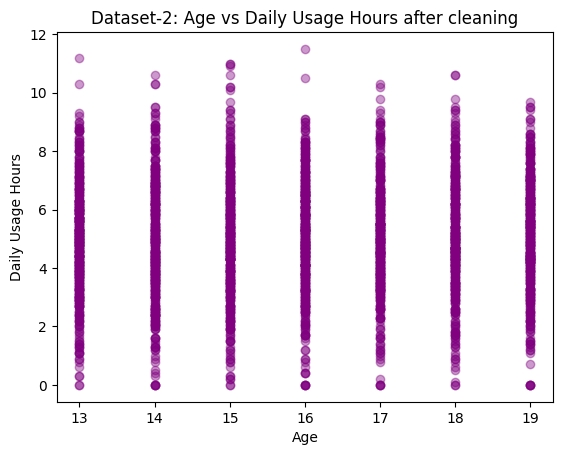

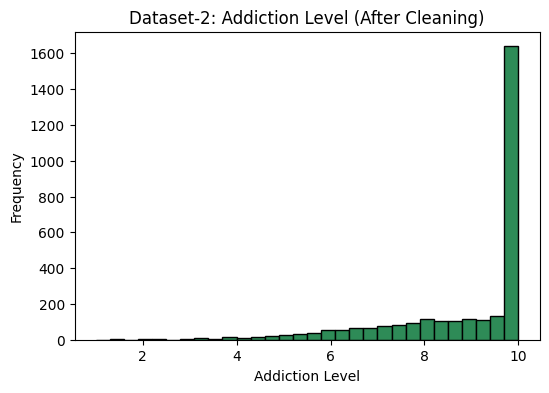

In [ ]:
# ===============================
# AFTER CLEANING - DATASET 2
# ===============================

print("after second dataset cleaned :")
print(df2)
print("--------------------------------------------")
print("Missing values for Dataset-2 after cleaning ")
print("--------------------------------------------")
print(df2.isnull().sum())

# Box Plot (Age)
plt.figure()
plt.boxplot(df2['age'])
plt.title("Dataset-2: Age after cleaning")
plt.show()

# Histogram (Sleep Hours)
plt.figure()
plt.hist(df2['sleep_hours'], bins=20, color="tan")
plt.title("Dataset-2: Sleep hours after cleaning")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot (Age vs Daily Usage Hours)
plt.figure()
plt.scatter(df2['age'], df2['daily_usage_hours'], alpha=0.4, color="purple")
plt.title("Dataset-2: Age vs Daily Usage Hours after cleaning")
plt.xlabel("Age")
plt.ylabel("Daily Usage Hours")
plt.show()

# Extra Histogram (Addiction Level)
plt.figure(figsize=(6,4))
plt.hist(df2['addiction_level'], bins=30, color="seagreen", edgecolor="black")
plt.title("Dataset-2: Addiction Level (After Cleaning)")
plt.xlabel("Addiction Level")
plt.ylabel("Frequency")
plt.show()
